In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../lessons/lesson_9/accommodation.csv')

/var/folders/4x/r5jmfhy116jd35yzhz5phw0w0000gn/T/ipykernel_15486/3397625352.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  category_cols = df.select_dtypes(include=["object"]).columns


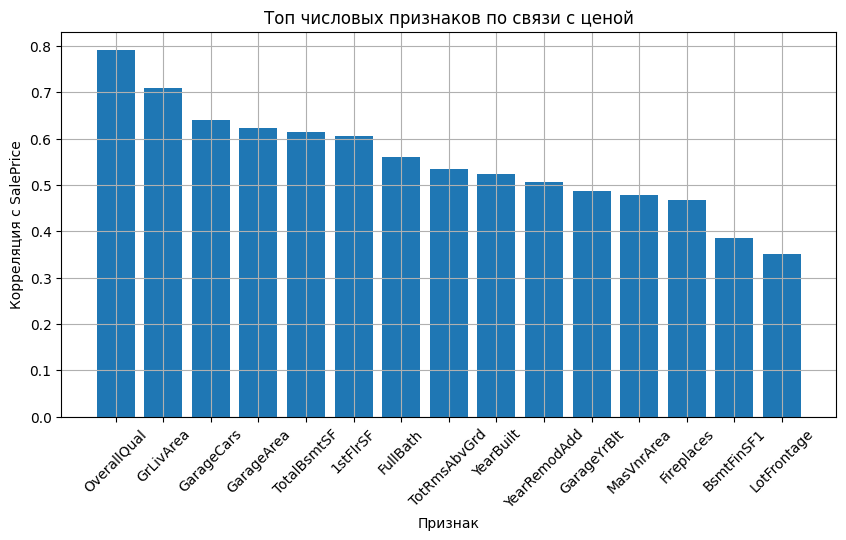

In [51]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
category_cols = df.select_dtypes(include=["object"]).columns

corr = (
    df[numeric_cols]
    .corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(ascending=False)
)

top_corr = corr.head(15)

plt.figure(figsize=(10, 5))
plt.bar(top_corr.index, top_corr.values)

plt.title("Топ числовых признаков по связи с ценой")
plt.xlabel("Признак")
plt.ylabel("Корреляция с SalePrice")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

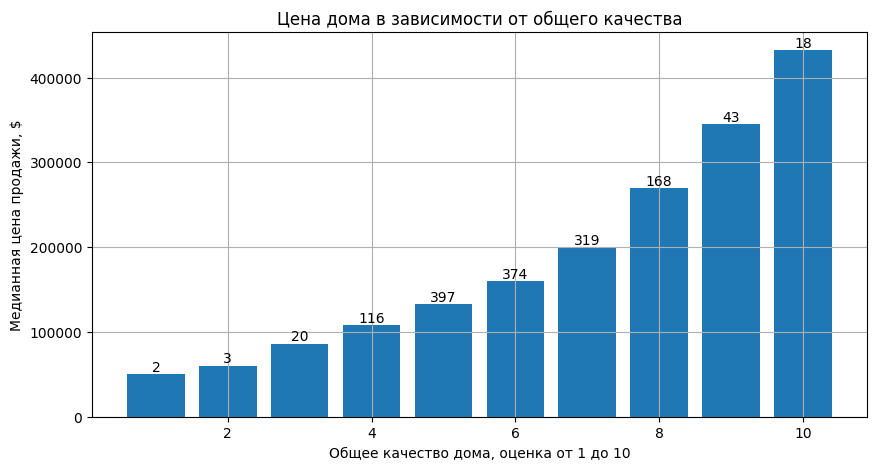

In [52]:
table = (
    df
    .groupby("OverallQual")
    .agg(
        median_price=("SalePrice", "median"),
        count=("SalePrice", "count")
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.bar(table["OverallQual"], table["median_price"])

for index, row in table.iterrows():
    plt.text(
        row["OverallQual"],
        row["median_price"],
        int(row["count"]),
        ha="center",
        va="bottom"
    )

plt.title("Цена дома в зависимости от общего качества")
plt.xlabel("Общее качество дома, оценка от 1 до 10")
plt.ylabel("Медианная цена продажи, $")
plt.grid(True)

plt.show()

# По графику видно, что медианная цена дома последовательно растёт вместе с увеличением общего качества дома. 
# Это означает, что между OverallQual и SalePrice есть выраженная положительная зависимость: чем выше качество дома, 
# тем выше его типичная цена продажи. Поэтому OverallQual можно считать одним из наиболее важных признаков для анализа стоимости дома.
# Однако для уровней качества, где количество домов небольшое, выводы менее надёжны, так как медианная цена рассчитана по малому числу объектов.

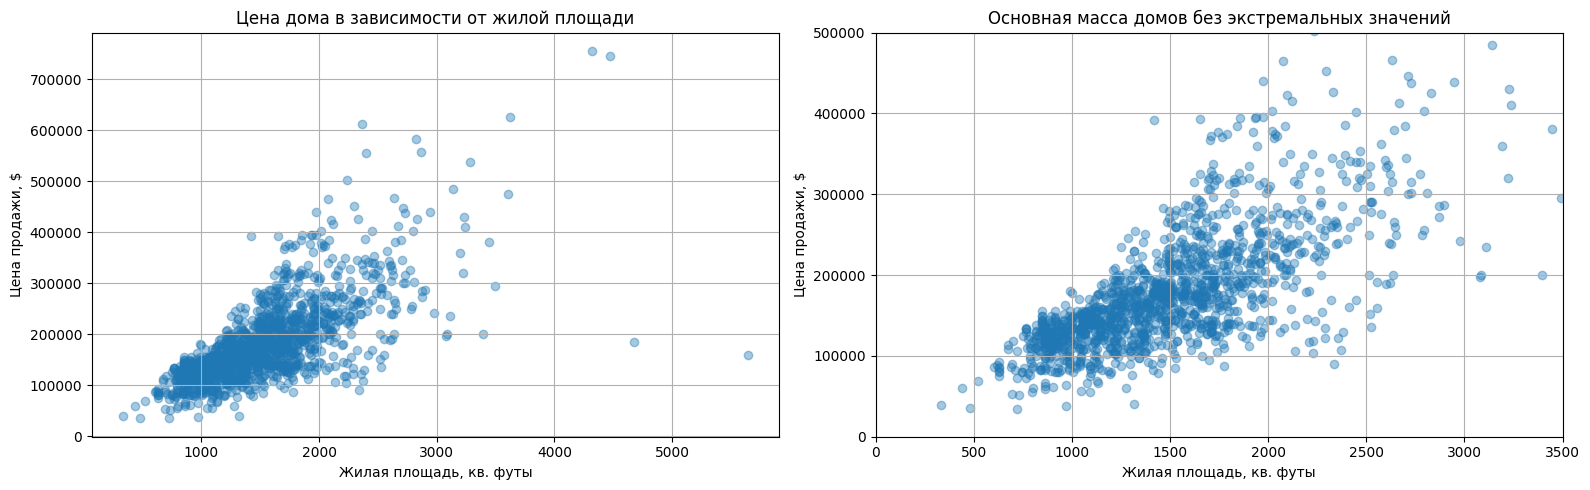

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(df["GrLivArea"], df["SalePrice"], alpha=0.4)
axes[0].set_title("Цена дома в зависимости от жилой площади")
axes[0].set_xlabel("Жилая площадь, кв. футы")
axes[0].set_ylabel("Цена продажи, $")
axes[0].grid(True)

axes[1].scatter(df["GrLivArea"], df["SalePrice"], alpha=0.4)
axes[1].set_xlim(0, 3500)
axes[1].set_ylim(0, 500000)
axes[1].set_title("Основная масса домов без экстремальных значений")
axes[1].set_xlabel("Жилая площадь, кв. футы")
axes[1].set_ylabel("Цена продажи, $")
axes[1].grid(True)


plt.tight_layout()
plt.show()

# На графике видно положительную связь между жилой площадью дома и ценой продажи: чем больше GrLivArea, 
# тем обычно выше SalePrice. Однако связь не идеальная — дома с похожей площадью могут сильно отличаться по цене. 
# Значит, площадь важна, но цена зависит не только от неё

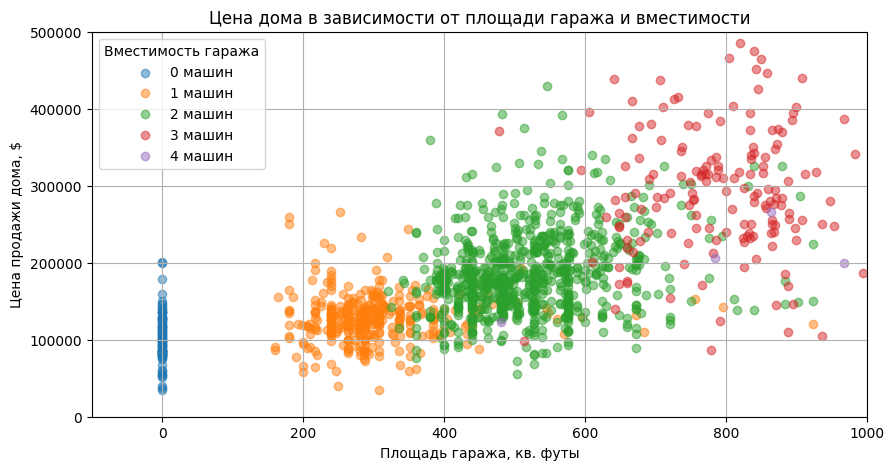

In [54]:
plt.figure(figsize=(10, 5))

for cars in sorted(df["GarageCars"].dropna().unique()):
    part = df[df["GarageCars"] == cars]

    plt.scatter(
        part["GarageArea"],
        part["SalePrice"],
        alpha=0.5,
        label=f"{int(cars)} машин"
    )

plt.title("Цена дома в зависимости от площади гаража и вместимости")
plt.xlabel("Площадь гаража, кв. футы")
plt.ylabel("Цена продажи дома, $")
plt.xlim(-100, 1000)
plt.ylim(0, 500000)
plt.legend(title="Вместимость гаража")
plt.grid(True)

plt.show()

# На scatter plot видно, что площадь и вместимость гаража имеют положительную связь с ценой дома, но эта связь не является строгой. 
# Дома без гаража и дома с гаражом на 1 машину частично находятся в похожем ценовом диапазоне, 
# поэтому сам факт наличия небольшого гаража не сильно отделяет дорогие дома от дешёвых. 
# Более заметное отличие видно у домов с гаражом на 2–3 машины: такие дома чаще имеют более высокую цену. 
# Однако разброс значений остаётся большим, поэтому гараж нельзя считать самостоятельным сильным фактором цены. 
# Скорее, он работает вместе с другими признаками: общей площадью дома, качеством, районом и годом постройки.

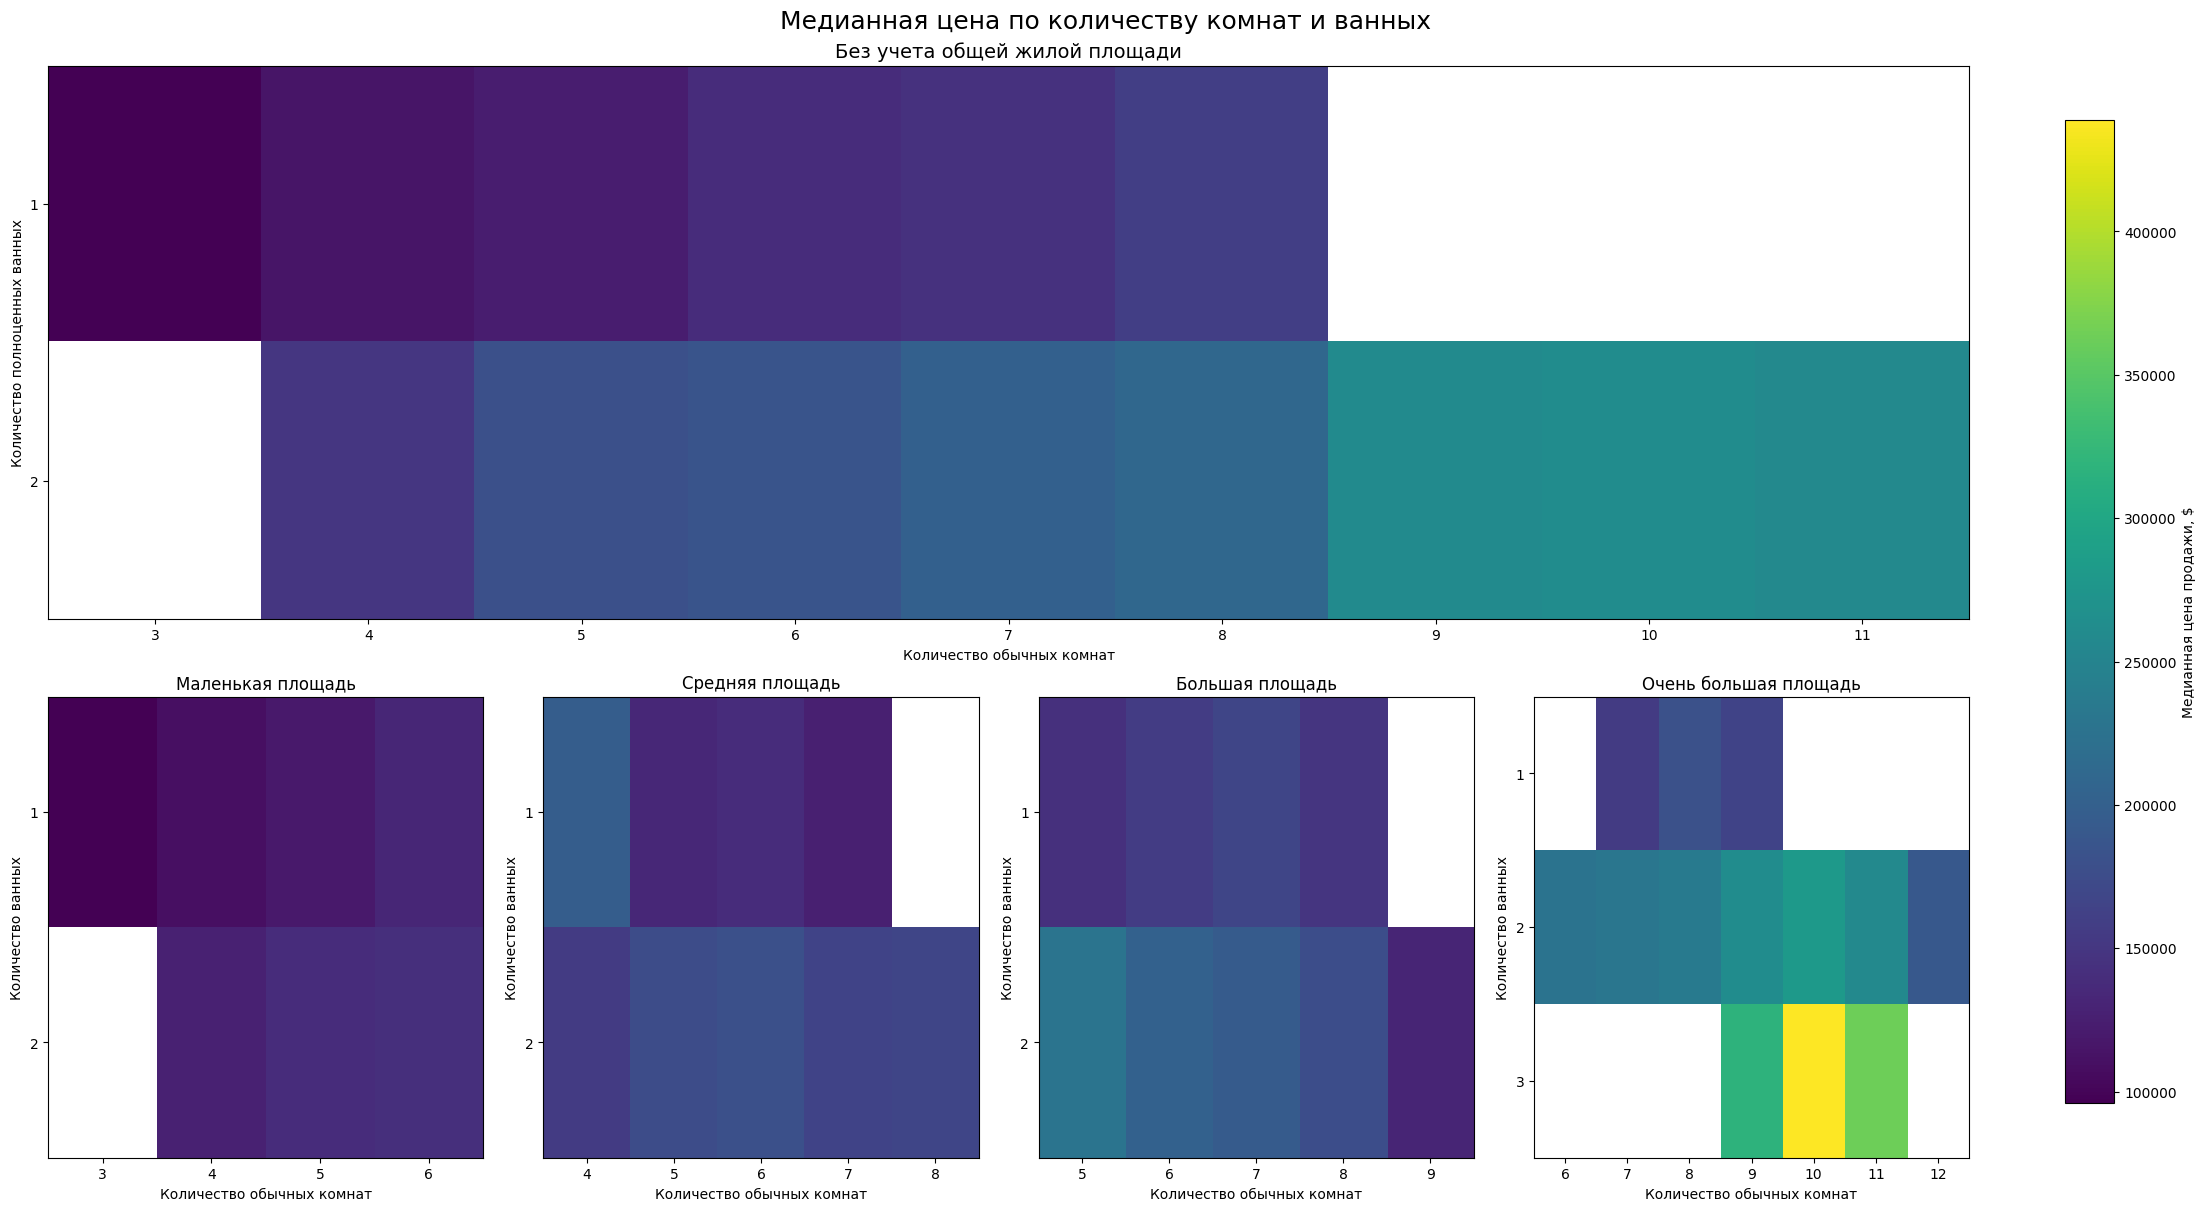

In [55]:
top_min_count = 10
bottom_min_count = 5

area_labels = [
    "Маленькая площадь",
    "Средняя площадь",
    "Большая площадь",
    "Очень большая площадь"
]

df_top = df[["FullBath", "TotRmsAbvGrd", "SalePrice"]].dropna().copy()

table_top = (
    df_top
    .groupby(["FullBath", "TotRmsAbvGrd"])
    .agg(
        median_price=("SalePrice", "median"),
        count=("SalePrice", "count")
    )
    .reset_index()
)

table_top_filtered = table_top[table_top["count"] >= top_min_count].copy()

pivot_top = table_top_filtered.pivot(
    index="FullBath",
    columns="TotRmsAbvGrd",
    values="median_price"
)

df_bottom = df[["GrLivArea", "FullBath", "TotRmsAbvGrd", "SalePrice"]].dropna().copy()

df_bottom["GrLivAreaGroup"] = pd.qcut(
    df_bottom["GrLivArea"],
    q=4,
    labels=area_labels
)

table_bottom = (
    df_bottom
    .groupby(["GrLivAreaGroup", "FullBath", "TotRmsAbvGrd"], observed=True)
    .agg(
        median_price=("SalePrice", "median"),
        count=("SalePrice", "count")
    )
    .reset_index()
)

table_bottom_filtered = table_bottom[table_bottom["count"] >= bottom_min_count].copy()

vmin = min(
    table_top_filtered["median_price"].min(),
    table_bottom_filtered["median_price"].min()
)

vmax = max(
    table_top_filtered["median_price"].max(),
    table_bottom_filtered["median_price"].max()
)

fig = plt.figure(figsize=(22, 12), constrained_layout=True)

gs = fig.add_gridspec(
    nrows=2,
    ncols=4,
    height_ratios=[1.2, 1]
)

ax_top = fig.add_subplot(gs[0, :])

axes_bottom = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
    fig.add_subplot(gs[1, 3])
]

img = ax_top.imshow(
    pivot_top,
    aspect="auto",
    vmin=vmin,
    vmax=vmax
)

ax_top.set_title("Без учета общей жилой площади", fontsize=14)
ax_top.set_xlabel("Количество обычных комнат")
ax_top.set_ylabel("Количество полноценных ванных")

ax_top.set_xticks(range(len(pivot_top.columns)))
ax_top.set_xticklabels(pivot_top.columns)

ax_top.set_yticks(range(len(pivot_top.index)))
ax_top.set_yticklabels(pivot_top.index)

for index, area_group in enumerate(area_labels):
    ax = axes_bottom[index]

    part = table_bottom_filtered[
        table_bottom_filtered["GrLivAreaGroup"] == area_group
    ]

    pivot_area = part.pivot(
        index="FullBath",
        columns="TotRmsAbvGrd",
        values="median_price"
    )

    img = ax.imshow(
        pivot_area,
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(str(area_group), fontsize=12)
    ax.set_xlabel("Количество обычных комнат")
    ax.set_ylabel("Количество ванных")

    ax.set_xticks(range(len(pivot_area.columns)))
    ax.set_xticklabels(pivot_area.columns)

    ax.set_yticks(range(len(pivot_area.index)))
    ax.set_yticklabels(pivot_area.index)

fig.suptitle(
    "Медианная цена по количеству комнат и ванных",
    fontsize=18
)

fig.colorbar(
    img,
    ax=[ax_top] + axes_bottom,
    label="Медианная цена продажи, $",
    shrink=0.9
)

plt.show()

# На верхней heatmap без учета жилой площади видно положительную связь:
# при увеличении количества обычных комнат и полноценных ванных медианная цена дома обычно растет.
#
# Особенно заметно, что дома с 2 ванными часто стоят дороже, чем дома с 1 ванной
# даже при сопоставимом количестве комнат. Например, дом с 8 комнатами и 1 ванной
# имеет медианную цену, близкую к дому с 4 комнатами и 2 ванными.
#
# Однако после разделения домов по общей жилой площади видно, что часть этой связи
# объясняется не самими комнатами и ванными, а размером дома. То есть дома с большим
# количеством комнат и ванных обычно имеют большую жилую площадь, а GrLivArea является
# одним из ключевых факторов цены.
#
# Внутри групп с похожей жилой площадью влияние количества комнат и ванных становится
# менее выраженным. Самый заметный разброс сохраняется в группе домов с очень большой
# площадью, особенно для домов с 3 ванными, но такие выводы нужно делать осторожно,
# потому что в этих комбинациях может быть мало наблюдений.

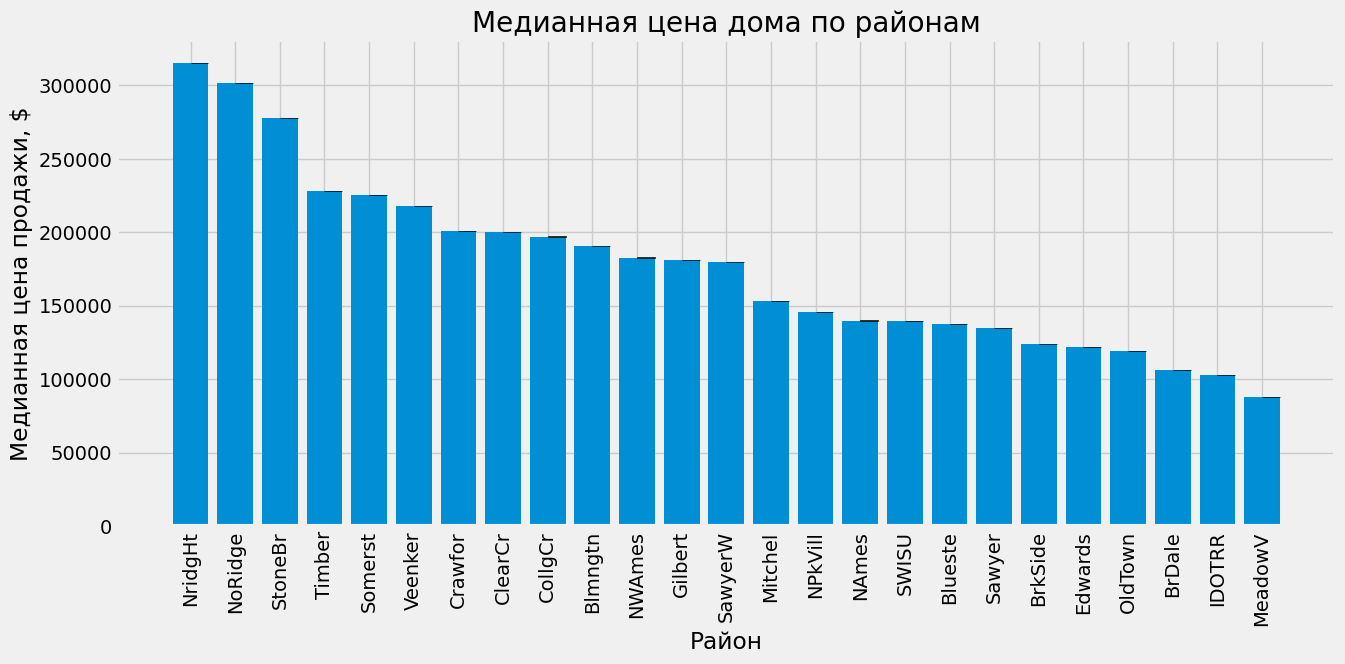

In [ ]:
table = (
    df
    .groupby("Neighborhood")
    .agg(
        median_price=("SalePrice", "median"),
        count=("SalePrice", "count")
    )
    .reset_index()
    .sort_values("median_price", ascending=False)
)

plt.figure(figsize=(14, 6))

plt.bar(table["Neighborhood"], table["median_price"])

for index, row in enumerate(table.itertuples()):
    plt.text(
        index,
        row.median_price + 5000,
        int(row.count),
        ha="center",
        va="bottom",
        rotation=90
    )

plt.title("Медианная цена дома по районам")
plt.xlabel("Район")
plt.ylabel("Медианная цена продажи, $")
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

# На графике видно, что медианная цена дома заметно отличается в зависимости от района. 
# Самые дорогие районы — NridgHt, NoRidge и StoneBr: медианная цена там находится примерно в диапазоне 280–315 тыс. $. 
# Самые дешёвые районы — MeadowV, IDOTRR, BrDale, OldTown и Edwards: медианная цена в них примерно от 90 до 125 тыс. $.
# Это говорит о том, что Neighborhood является важным категориальным признаком для анализа стоимости дома. 
# Район сильно связан с ценой продажи.